# Binary Classification with a Pretrained Backbone (DenseNet-121)

Transfer learning from an ImageNet-pretrained DenseNet-121, the architecture
behind CheXNet. We train a fresh head on the frozen backbone, then fine-tune the
top of the backbone at a low learning rate.

## Setup

In [ ]:
# One-time setup: make the `visualization` helper importable, then fetch data +
# resolve paths. Each study's fetch logic lives in its own download_data.py.
import os
import sys

if "google.colab" in sys.modules:
    if not os.path.isdir("ConvolutedComputerVision"):
        !git clone -q https://github.com/samlowe106/ConvolutedComputerVision.git
    sys.path.insert(0, "ConvolutedComputerVision/src")

from visualization import colab_bootstrap

DATA_ROOT, CKPT_ROOT = colab_bootstrap(study="chest-x-ray-images-pneumonia")

In [2]:
import datetime

import numpy as np
import tensorflow as tf
from sklearn.metrics import precision_recall_curve

notebook_start_time = datetime.datetime.now()

In [3]:
test_dir = f"{DATA_ROOT}/test"
train_dir = f"{DATA_ROOT}/train"
validation_dir = f"{DATA_ROOT}/val"

# DenseNet-121 (ImageNet) expects 224x224 RGB; the grayscale X-rays load as 3 equal channels
height, width, channels = 224, 224, 3

batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="rgb",
)

# validation/test are shuffle=False so labels stay aligned with model.predict
validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="rgb",
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(height, width),
    batch_size=batch_size,
    label_mode="int",
    color_mode="rgb",
    shuffle=False,
)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

Found 4461 files belonging to 2 classes.
Found 771 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [ ]:
from visualization import (
    class_weights,
    reset_keras,
    show_confusion_matrix,
    show_gradcam,
    summary_graphics,
)

In [ ]:
class_weight = class_weights(train_ds, cache_dir=DATA_ROOT)

print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

## Model: DenseNet-121 transfer learning

Instead of learning features from our ~4.4k images, we borrow them from a
DenseNet-121 pretrained on ImageNet (1.3M images). The recipe is two phases:

1. **Freeze** the backbone and train only a fresh classifier head. It is fast, and it
   adapts the head to the pretrained features without disturbing them.
2. **Unfreeze** the top of the backbone and continue at a very low learning rate,
   nudging the high-level features toward chest X-rays.

DenseNet-121 at 224x224 is **heavy on CPU**, so expect slow epochs. To iterate
faster, swap the backbone to `MobileNetV2` (see the comment in the model cell).

In [6]:
metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    tf.keras.metrics.AUC(name="auc"),
]


def make_callbacks(filepath):
    # select on val AUC (threshold-free, robust to the class imbalance)
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=filepath, save_best_only=True, monitor="val_auc", mode="max"
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=4, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5, patience=2
        ),
    ]


epochs = 10

In [7]:
reset_keras()

# DenseNet-121 is the chest-X-ray standard, but heavy on CPU. To iterate faster,
# swap both lines for MobileNetV2 + tf.keras.applications.mobilenet_v2.preprocess_input.
backbone = tf.keras.applications.DenseNet121
preprocess_input = tf.keras.applications.densenet.preprocess_input

base_model = backbone(
    include_top=False, weights="imagenet", input_shape=(height, width, channels)
)
base_model.trainable = False  # phase 1: frozen feature extractor

inputs = tf.keras.Input((height, width, channels), name="input")
# light augmentation (no horizontal flip, which is anatomically wrong for chest X-rays)
x = tf.keras.layers.RandomRotation(0.1)(inputs)
x = tf.keras.layers.RandomTranslation(0.1, 0.1)(x)
x = preprocess_input(x)  # DenseNet's expected input normalization
x = base_model(x, training=False)  # training=False keeps BatchNorm in inference mode
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(x)
model_1 = tf.keras.Model(inputs, outputs, name="densenet121_transfer")

model_1.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)
model_1.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "densenet121_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 224, 224, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

## Phase 1: train the head on the frozen backbone

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.8332 - auc: 0.9153 - loss: 0.1915 - precision: 0.9368 - recall: 0.8317 - tn: 960.0000 - tp: 2757.0000 - val_accuracy: 0.9442 - val_auc: 0.9840 - val_loss: 0.1510 - val_precision: 0.9597 - val_recall: 0.9648 - val_tn: 180.0000 - val_tp: 548.0000 - learning_rate: 0.0010
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 52s 368ms/step - accuracy: 0.8915 - auc: 0.9576 - loss: 0.1352 - precision: 0.9585 - recall: 0.8926 - tn: 1018.0000 - tp: 2959.0000 - val_accuracy: 0.9351 - val_auc: 0.9868 - val_loss: 0.1566 - val_precision: 0.9814 - val_recall: 0.9296 - val_tn: 193.0000 - val_tp: 528.0000 - learning_rate: 0.0010
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 54s 386ms/step - accuracy: 0.8884 - auc: 0.9586 - loss: 0.1339 - precision: 0.9607 - recall: 0.8860 - tn: 1026.0000 - tp: 2937.0000 - val_accuracy: 0.9092 - val_auc: 0.9876 - val_loss: 0.2065 - val_precision: 0.9882 - val_recall: 0.8873 - val_tn: 197.0000 - val_tp: 504.0000 - learning

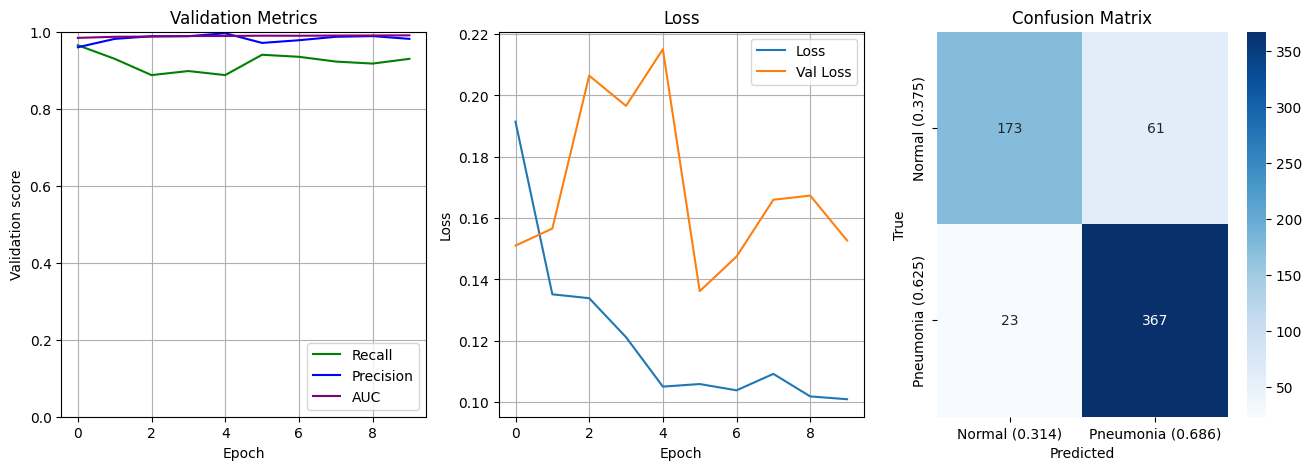

In [8]:
history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks(os.path.join(CKPT_ROOT, "best_model_head.keras")),
)
summary_graphics(history, model_1, test_ds)

## Phase 2: fine-tune the top of the backbone

Unfreeze the backbone and continue at a much lower learning rate. We keep the base
in inference mode for BatchNorm (`training=False` above), so only the conv weights
move gently, so we don't wreck the pretrained features.

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 206s 902ms/step - accuracy: 0.9018 - auc: 0.9429 - loss: 0.2709 - precision: 0.9173 - recall: 0.9536 - tn: 1015.0000 - tp: 3703.0000 - val_accuracy: 0.9494 - val_auc: 0.9861 - val_loss: 0.1518 - val_precision: 0.9715 - val_recall: 0.9595 - val_tn: 187.0000 - val_tp: 545.0000 - learning_rate: 1.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 118s 839ms/step - accuracy: 0.9336 - auc: 0.9804 - loss: 0.0947 - precision: 0.9788 - recall: 0.9309 - tn: 1079.0000 - tp: 3086.0000 - val_accuracy: 0.9494 - val_auc: 0.9863 - val_loss: 0.1398 - val_precision: 0.9732 - val_recall: 0.9577 - val_tn: 188.0000 - val_tp: 544.0000 - learning_rate: 1.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 118s 841ms/step - accuracy: 0.9384 - auc: 0.9822 - loss: 0.0881 - precision: 0.9801 - recall: 0.9360 - tn: 1083.0000 - tp: 3103.0000 - val_accuracy: 0.9507 - val_auc: 0.9907 - val_loss: 0.1285 - val_precision: 0.9801 - val_recall: 0.9525 - val_tn: 192.0000 - val_tp: 541.0

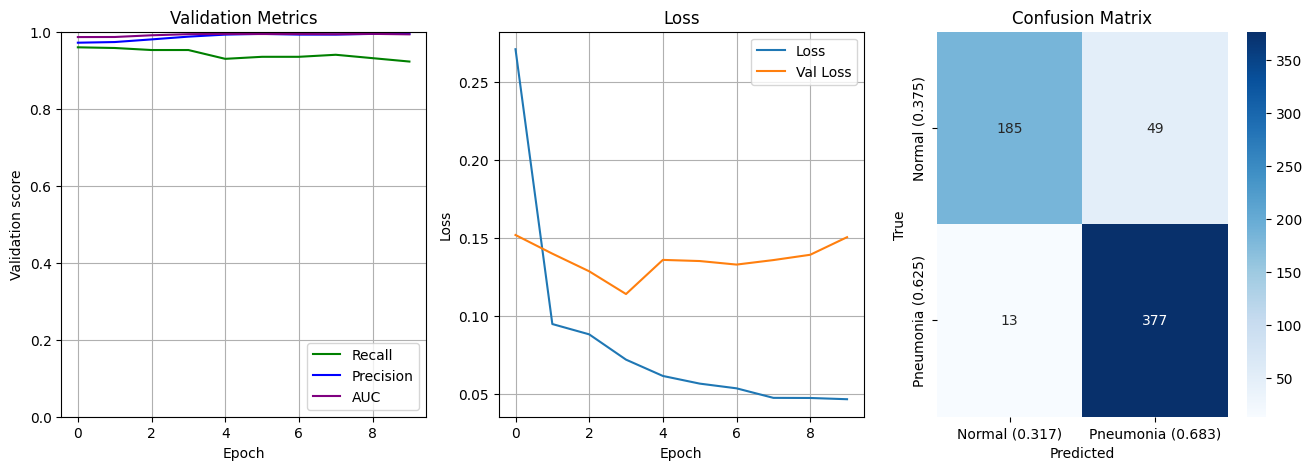

In [9]:
base_model.trainable = True

model_1.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5),  # low LR for fine-tuning
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics,
)

ckpt_path = os.path.join(CKPT_ROOT, "best_model.keras")
history = model_1.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=epochs,
    class_weight=class_weight,
    verbose=1,
    callbacks=make_callbacks(ckpt_path),
)
best_model = tf.keras.models.load_model(ckpt_path)
summary_graphics(history, best_model, test_ds)

## Tuning the decision threshold

At the default 0.5 cutoff a high-precision/low-recall model produces many false
negatives. We pick the threshold that maximizes F1 on the **validation** set and
apply it to the **test** set.

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 328ms/step
Tuned threshold: 0.064  (default is 0.5)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step
   default 0.5: accuracy=0.901  recall=0.967  precision=0.885  false negatives=13
   tuned 0.064: accuracy=0.825  recall=0.995  precision=0.784  false negatives=2


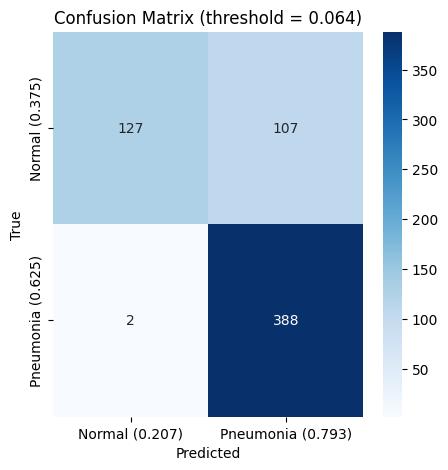

In [10]:
# Choose the decision threshold on the VALIDATION set (never on test), then apply it
# to test. A lower threshold trades a little precision for far fewer false negatives.
val_probs = best_model.predict(validation_ds).ravel()
y_val = np.concatenate([y for _, y in validation_ds], axis=0)

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
threshold = float(thresholds[np.argmax(f1)])
print(f"Tuned threshold: {threshold:.3f}  (default is 0.5)\n")

test_probs = best_model.predict(test_ds).ravel()
y_test = np.concatenate([y for _, y in test_ds], axis=0)

for name, thr in [("default 0.5", 0.5), (f"tuned {threshold:.3f}", threshold)]:
    pred = (test_probs >= thr).astype("int32")
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    print(
        f"{name:>14}: accuracy={np.mean(pred == y_test):.3f}  "
        f"recall={tp / (tp + fn):.3f}  precision={tp / (tp + fp):.3f}  "
        f"false negatives={fn}"
    )

show_confusion_matrix(
    y_test,
    (test_probs >= threshold).astype("int32"),
    title=f"Confusion Matrix (threshold = {threshold:.3f})",
)

## Grad-CAM: where is the model looking?

Grad-CAM weights the last convolutional feature map by the gradient of the pneumonia score, showing which regions drove the prediction. On the model's most confident pneumonia case it should highlight a lung field rather than the image borders. (Chest X-ray nets are prone to shortcut learning on burned-in text or scanner artifacts.)

In [ ]:
# Grad-CAM on the model's most confident PNEUMONIA case: it should highlight a lung
# field, not the image borders.
y_test = np.concatenate([y for _, y in test_ds], axis=0)
test_probs = best_model.predict(test_ds).ravel()
pos_i = max(
    (i for i in range(len(y_test)) if y_test[i] == 1), key=lambda i: test_probs[i]
)
all_images = np.concatenate([bx.numpy() for bx, _ in test_ds], axis=0)

show_gradcam(
    all_images[pos_i].astype("uint8"),
    best_model,
    class_name="pneumonia",
    true_label="pneumonia",
    title="Grad-CAM: most confident pneumonia case (DenseNet-121)",
)

In [11]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} "
    f"(duration: {notebook_end_time - notebook_start_time})"
)

Notebook last run (end-to-end): 2026-07-10 07:06:53.184146 (duration: 0:57:54.040225)
